# 🔵 Customer Churn Segmentation — K-Means Clustering

**Version:** 1.0  

**Last run:** <!-- Need to fill date -->  

**Dataset:** IBM Telco Customer Churn (7,043 customers)

**Algorithm:** K-Means with StandardScaler preprocessing

**Goal:** Identify distinct behavioral customer segments to enable
targeted, segment-specific churn intervention strategies.

---

## Notebook structure

| Part | What it does |
|------|-------------|
| **A** | Feature selection & encoding |
| **B** | Optimal k selection (Elbow + Silhouette + Calinski-Harabasz) |
| **C** | Fit final model → profile each cluster → assign business names |
| **D** | Visualizations: PCA scatter, bar charts, radar, heatmap |
| **E** | Export for Power BI + save ML artifacts |

**Prerequisites:** Run `Churn_Analysis_Cleaning notebook` and `SQL_Analysis notebook` first.
The database at `../data/cleaned/telco_churn.db` must have engineered
columns: `churn_binary`, `services_count`, `tenure_band`, `has_security`.

**Key output:** `../data/cleaned/telco_churn_clustered.csv`
(original data + Cluster column for Power BI ingestion)

## Imports & Database Connection

In [68]:
# Cell: Setup — all imports in one place for reproducibility
import os
import json
import warnings
import sqlite3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.decomposition import PCA  # For Part D scatter plot

warnings.filterwarnings("ignore", category=UserWarning)

# ── Reproducibility ──────────────────────────────────────
RANDOM_STATE = 42

# ── Plotting style ───────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

print("✅ All libraries loaded successfully")


✅ All libraries loaded successfully


###  Load Data from Your SQLite Database

In [45]:
# Cell: Load data from the database
db_path = "../data/cleaned/telco_churn.db"
table_name = "customers"

with sqlite3.connect(db_path) as conn:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)

print(f"✅ Loaded {len(df)} customers, {df.shape[1]} columns")

required_cols = [
    "customerID", "tenure", "MonthlyCharges", "TotalCharges",
    "Contract", "PaymentMethod", "has_security", "SeniorCitizen",
    "services_count", "churn_binary"
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Coerce numeric fields
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["MonthlyCharges"] = pd.to_numeric(df["MonthlyCharges"], errors="coerce")
df["tenure"] = pd.to_numeric(df["tenure"], errors="coerce")

# Basic missing-value summary
na_summary = df[required_cols].isna().sum()
print("Missing values:")
print(na_summary[na_summary > 0])

print(f"Churned: {df['churn_binary'].sum()} ({df['churn_binary'].mean()*100:.1f}%)")
print(f"Retained: {(df['churn_binary']==0).sum()}")
df.head()

✅ Loaded 7043 customers, 26 columns
Missing values:
Series([], dtype: int64)
Churned: 1869 (26.5%)
Retained: 5174


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_band,monthly_charges_band,services_count,has_security,churn_binary
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,Yes,Electronic check,29.85,29.85,No,0-12 months,Low (<$35),1,No,0
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,Mailed check,56.95,1889.50,No,25-36 months,Medium ($35-$70),3,Yes,0
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,Yes,Mailed check,53.85,108.15,Yes,0-12 months,Medium ($35-$70),3,Yes,1
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,No,Bank transfer (automatic),42.30,1840.75,No,37-48 months,Medium ($35-$70),3,Yes,0
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,Yes,Electronic check,70.70,151.65,Yes,0-12 months,High ($70+),1,No,1


## Part A: Feature Selection & Encoding

### Select Features for Clustering

In [46]:
# Cell: Select the features that matter for churn behavior
# WHY these features? They represent the 4 dimensions of customer behavior:
#   1. HOW LONG they've been here (tenure)
#   2. HOW MUCH they pay (MonthlyCharges)
#   3. HOW DEEP they're embedded (services_count)
#   4. HOW COMMITTED they are (Contract type)
#   5. HOW they pay (PaymentMethod — auto vs manual)
#   6. WHETHER they have protection (has_security)

# We cluster ALL customers, not just churned ones
# This way we can see churn RATE per cluster

# Cell 4: Select features for clustering
features_for_clustering = [
    "tenure",
    "MonthlyCharges",
    "services_count",
    "Contract",
    "PaymentMethod",
    "has_security",
    "SeniorCitizen",
]

# We carry along churn_binary and TotalCharges for post-hoc analysis,
# but they are NOT used as clustering features.
df_cluster = df[features_for_clustering + ["churn_binary", "TotalCharges", "customerID"]].copy()

# Drop rows with missing values in clustering features
before = len(df_cluster)
df_cluster = df_cluster.dropna(subset=features_for_clustering)


after = len(df_cluster)
if after < before:
    print(f"⚠️ Dropped {before - after} rows with missing values in clustering features")

print(f"✅ Selected {len(features_for_clustering)} features for clustering")
print(f"Shape: {df_cluster.shape}")
df_cluster.head()


✅ Selected 7 features for clustering
Shape: (7043, 10)


,tenure,MonthlyCharges,services_count,Contract,PaymentMethod,has_security,SeniorCitizen,churn_binary,TotalCharges,customerID
0,1,29.85,1,Month-to-month,Electronic check,No,No,0,29.85,7590-VHVEG
1,34,56.95,3,One year,Mailed check,Yes,No,0,1889.50,5575-GNVDE
2,2,53.85,3,Month-to-month,Mailed check,Yes,No,1,108.15,3668-QPYBK
3,45,42.30,3,One year,Bank transfer (automatic),Yes,No,0,1840.75,7795-CFOCW
4,2,70.70,1,Month-to-month,Electronic check,No,No,1,151.65,9237-HQITU


### Encode Categorical Variables

In [47]:
# Cell: Encode categorical features
contract_map = {"Month-to-month": 0, "One year": 1, "Two year": 2}
df_cluster["Contract_encoded"] = df_cluster["Contract"].map(contract_map)

payment_map = {
    "Electronic check": 0,
    "Mailed check": 0,
    "Bank transfer (automatic)": 1,
    "Credit card (automatic)": 1,
}
df_cluster["AutoPay"] = df_cluster["PaymentMethod"].map(payment_map)

df_cluster["Security_encoded"] = df_cluster["has_security"].map({"Yes": 1, "No": 0})

# Normalize SeniorCitizen to 0/1
df_cluster["Senior_encoded"] = df_cluster["SeniorCitizen"].map(
    {"Yes": 1, "No": 0, 1: 1, 0: 0}
)

numeric_features = [
    "tenure", "MonthlyCharges", "services_count",
    "Contract_encoded", "AutoPay", "Security_encoded", "Senior_encoded"
]

if df_cluster[numeric_features].isna().any().any():
    raise ValueError("Nulls detected after encoding; check mappings.")

print("✅ Encoding complete")
df_cluster[numeric_features].describe().round(2)

✅ Encoding complete


,tenure,MonthlyCharges,services_count,Contract_encoded,AutoPay,Security_encoded,Senior_encoded
count,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00
mean,32.37,64.76,3.36,0.69,0.44,0.42,0.16
std,24.56,30.09,2.06,0.83,0.50,0.49,0.37
min,0.00,18.25,0.00,0.00,0.00,0.00,0.00
25%,9.00,35.50,1.00,0.00,0.00,0.00,0.00
50%,29.00,70.35,3.00,0.00,0.00,0.00,0.00
75%,55.00,89.85,5.00,1.00,1.00,1.00,0.00
max,72.00,118.75,8.00,2.00,1.00,1.00,1.00


### Scale Features

In [48]:
# Cell: Normalize all features to same scale
# WHY? K-Means uses DISTANCE. tenure ranges 0-72, MonthlyCharges 18-118.
# Without scaling, tenure would dominate just because its numbers are bigger.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[numeric_features])

# X_scaled is a NumPy array. Consider wrapping it in a DataFrame for easier debugging
X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_features, index=df_cluster.index)

print(f"✅ Scaled {X_scaled.shape[1]} features")
print(f"Mean of each feature (should be ~0): {X_scaled.mean(axis=0).round(4)}")
print(f"Std of each feature (should be ~1):  {X_scaled.std(axis=0).round(4)}")

✅ Scaled 7 features
Mean of each feature (should be ~0): [-0. -0. -0. -0.  0. -0. -0.]
Std of each feature (should be ~1):  [1. 1. 1. 1. 1. 1. 1.]


## Part B: Find Optimal Number of Clusters

### Elbow Curve + Silhouette Scores

k=2: Inertia=34,920  Silhouette=0.2789  Calinski-Harabasz=2899.6
k=3: Inertia=28,718  Silhouette=0.2466  Calinski-Harabasz=2522.8
k=4: Inertia=23,646  Silhouette=0.2993  Calinski-Harabasz=2545.8
k=5: Inertia=20,353  Silhouette=0.2853  Calinski-Harabasz=2502.6
k=6: Inertia=18,118  Silhouette=0.2885  Calinski-Harabasz=2422.4
k=7: Inertia=16,539  Silhouette=0.3057  Calinski-Harabasz=2323.0
k=8: Inertia=15,061  Silhouette=0.3150  Calinski-Harabasz=2284.7


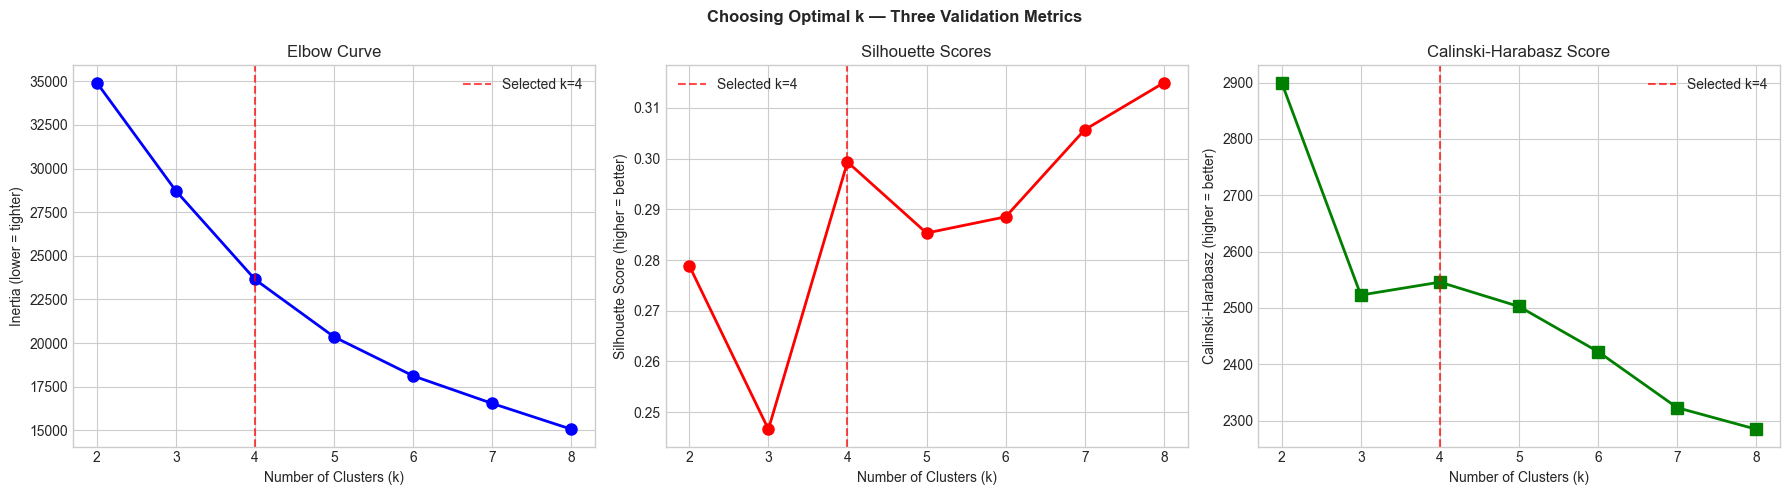

✅ Saved. Selected k=4 based on elbow inflection + silhouette peak.


In [49]:
from sklearn.metrics import calinski_harabasz_score
K_range = range(2, 9)
inertias, silhouettes, calinski = [], [], []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(
        silhouette_score(X_scaled, labels) if len(np.unique(labels)) > 1 else np.nan
    )
    calinski.append(calinski_harabasz_score(X_scaled, labels))
    print(f"k={k}: Inertia={km.inertia_:,.0f}  "
          f"Silhouette={silhouettes[-1]:.4f}  "
          f"Calinski-Harabasz={calinski[-1]:.1f}")
# ── Why k=4? ──────────────────────────────────────────────
# k=4 shows:
#   - Clear elbow inflection (diminishing inertia returns beyond k=4)
#   - Local silhouette peak (0.2993) relative to k=3 (0.2466)
#   - Local Calinski-Harabasz peak
#   - 4 segments aligns with recognizable business archetypes
#     (new/at-risk, low-value stable, mid-value, high-value loyal)
OPTIMAL_K = 4

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Choosing Optimal k — Three Validation Metrics', fontweight='bold')

# Elbow curve
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=OPTIMAL_K, color='red', linestyle='--', alpha=0.7,
                label=f'Selected k={OPTIMAL_K}')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (lower = tighter)')
axes[0].set_title('Elbow Curve')
axes[0].set_xticks(list(K_range))
axes[0].legend()

# Silhouette scores
axes[1].plot(K_range, silhouettes, 'ro-', linewidth=2, markersize=8)
axes[1].axvline(x=OPTIMAL_K, color='red', linestyle='--', alpha=0.7,
                label=f'Selected k={OPTIMAL_K}')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score (higher = better)')
axes[1].set_title('Silhouette Scores')
axes[1].set_xticks(list(K_range))
axes[1].legend()

# Calinski-Harabasz
axes[2].plot(K_range, calinski, 'gs-', linewidth=2, markersize=8)
axes[2].axvline(x=OPTIMAL_K, color='red', linestyle='--', alpha=0.7,
                label=f'Selected k={OPTIMAL_K}')
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('Calinski-Harabasz (higher = better)')
axes[2].set_title('Calinski-Harabasz Score')
axes[2].set_xticks(list(K_range))
axes[2].legend()

plt.tight_layout()
os.makedirs('../docs', exist_ok=True)
plt.savefig('../docs/elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved. Selected k={OPTIMAL_K} based on elbow inflection + silhouette peak.")


- `Elbow curve`: Look for where the line "bends" — that's where adding more clusters stops helping much.
- `Silhouette score`: Higher = better. Pick the k with the highest score, or the one before a big drop.

We selected k = 4 as the optimal number of clusters.
The elbow curve shows a clear inflection at k=4, indicating diminishing returns beyond this point.
While silhouette scores continue to increase slightly for higher k, the marginal gain is minimal.
Therefore, k=4 provides the best trade-off between cluster quality and business interpretability.

## HEALTH SCORE BEFORE CLUSTERING

### Load Clustered Data (if starting fresh session)

In [50]:
# Cell 14: Load your clustered data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

conn = sqlite3.connect('../data/cleaned/telco_churn.db')
df = pd.read_sql("SELECT * FROM customers_clustered", conn)
conn.close()

print(f"✅ Loaded {len(df)} customers with {df.shape[1]} columns")
print(f"Columns include Cluster: {('Cluster' in df.columns)}")
print(f"Columns include Cluster_Name: {('Cluster_Name' in df.columns)}")

✅ Loaded 7043 customers with 28 columns
Columns include Cluster: True
Columns include Cluster_Name: True


### Build the Health Score

In [51]:
# Cell: Customer Health Score — Weighted Composite
# 
# WHY THESE WEIGHTS?
# - Tenure (0.25): Longer customers are proven stayers — strongest signal
# - Contract (0.25): Annual/2-year = committed. M2M = flight risk
# - Service depth (0.20): More services = more switching cost = stickier
# - Payment method (0.15): Auto-pay = less friction = less likely to cancel
# - Tech support (0.15): Has support = feels supported = less frustrated

def calculate_health_score(row):
    """
    Score each customer 0-100 based on 5 behavioral dimensions.
    Higher = healthier (less likely to churn).
    """
    # 1. TENURE SCORE (0-25 points)
    # Logic: 0 months = 0 points, 72 months = 25 points (linear scale)
    tenure_score = min(row['tenure'] / 72.0, 1.0) * 25
    
    # 2. CONTRACT SCORE (0-25 points)
    # Logic: M2M = 0, One year = 15, Two year = 25
    contract_map = {'Month-to-month': 0, 'One year': 15, 'Two year': 25}
    contract_score = contract_map.get(row['Contract'], 0)
    
    # 3. SERVICE DEPTH SCORE (0-20 points)
    # Logic: 0 services = 0, 8 services = 20 (linear scale)
    service_score = min(row['services_count'] / 8.0, 1.0) * 20
    
    # 4. PAYMENT METHOD SCORE (0-15 points)
    # Logic: Auto-pay methods = 15, Manual = 5, Electronic check = 0
    if 'automatic' in str(row['PaymentMethod']).lower() or 'credit card' in str(row['PaymentMethod']).lower():
        payment_score = 15
    elif 'mailed check' in str(row['PaymentMethod']).lower():
        payment_score = 5
    else:  # Electronic check — worst
        payment_score = 0
    
    # 5. TECH SUPPORT SCORE (0-15 points)
    # Logic: Has security/support = 15, No = 0
    support_score = 15 if row.get('has_security', 'No') == 'Yes' else 0
    
    return round(tenure_score + contract_score + service_score + payment_score + support_score, 1)

# Apply to every customer
df['health_score'] = df.apply(calculate_health_score, axis=1)

# Assign risk tiers
def assign_risk_tier(score):
    if score <= 39:
        return '🔴 Red (High Risk)'
    elif score <= 69:
        return '🟡 Yellow (Medium Risk)'
    else:
        return '🟢 Green (Low Risk)'

df['risk_tier'] = df['health_score'].apply(assign_risk_tier)

print("✅ Health Score calculated for all customers")
print(f"\nHealth Score Stats:")
print(df['health_score'].describe().round(1))
print(f"\nRisk Tier Distribution:")
print(df['risk_tier'].value_counts())


✅ Health Score calculated for all customers

Health Score Stats:
count    7043.0
mean       42.8
std        27.7
min         0.3
25%        18.9
50%        39.4
75%        64.0
max       100.0
Name: health_score, dtype: float64

Risk Tier Distribution:
risk_tier
🔴 Red (High Risk)         3493
🟡 Yellow (Medium Risk)    2124
🟢 Green (Low Risk)        1426
Name: count, dtype: int64


### Validate: Does Health Score Actually Predict Churn?

In [52]:
# Cell: VALIDATION — Does our score actually work?
# A good health score should show: Red customers churn WAY more than Green ones

validation = df.groupby('risk_tier').agg(
    customers=('customerID', 'count'),
    churned=('churn_binary', 'sum'),
    churn_rate=('churn_binary', 'mean'),
    avg_health_score=('health_score', 'mean'),
    avg_monthly_charges=('MonthlyCharges', 'mean'),
    avg_tenure=('tenure', 'mean'),
    total_monthly_revenue=('MonthlyCharges', 'sum')
).round(2)

validation['churn_rate'] = (validation['churn_rate'] * 100).round(1)
validation['pct_of_customers'] = (validation['customers'] / len(df) * 100).round(1)
validation['pct_of_churners'] = (validation['churned'] / df['churn_binary'].sum() * 100).round(1)

print("=" * 70)
print("HEALTH SCORE VALIDATION — Does it predict churn?")
print("=" * 70)
print(validation[['customers', 'pct_of_customers', 'churned', 'pct_of_churners', 
                   'churn_rate', 'avg_health_score']])
print()
print("✅ If Red has high churn rate and Green has low — your score WORKS!")
print("❌ If they're similar — your weights need adjustment")


HEALTH SCORE VALIDATION — Does it predict churn?
                        customers  pct_of_customers  churned  pct_of_churners  \
risk_tier                                                                       
🔴 Red (High Risk)            3493              49.6     1494             79.9   
🟡 Yellow (Medium Risk)       2124              30.2      288             15.4   
🟢 Green (Low Risk)           1426              20.2       87              4.7   

                        churn_rate  avg_health_score  
risk_tier                                             
🔴 Red (High Risk)             43.0             19.15  
🟡 Yellow (Medium Risk)        14.0             53.45  
🟢 Green (Low Risk)             6.0             84.79  

✅ If Red has high churn rate and Green has low — your score WORKS!
❌ If they're similar — your weights need adjustment


### Health Score Distribution Chart

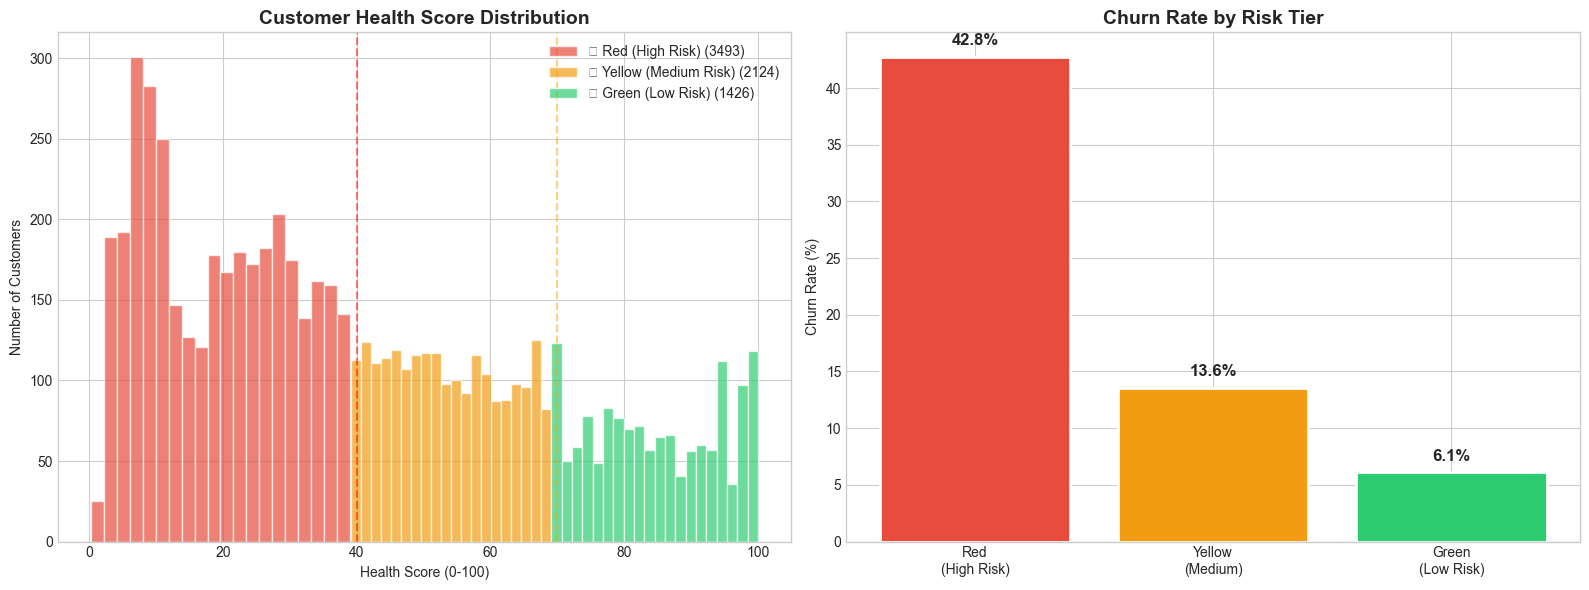

✅ Saved to docs/health_score_distribution.png


In [53]:
# Cell: Visualize the health score distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Histogram colored by risk tier
colors_map = {'🔴 Red (High Risk)': '#e74c3c', 
              '🟡 Yellow (Medium Risk)': '#f39c12', 
              '🟢 Green (Low Risk)': '#2ecc71'}

for tier, color in colors_map.items():
    subset = df[df['risk_tier'] == tier]
    axes[0].hist(subset['health_score'], bins=20, alpha=0.7, color=color, 
                 label=f"{tier} ({len(subset)})", edgecolor='white')

axes[0].set_title('Customer Health Score Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Health Score (0-100)')
axes[0].set_ylabel('Number of Customers')
axes[0].legend()
axes[0].axvline(x=40, color='red', linestyle='--', alpha=0.5)
axes[0].axvline(x=70, color='orange', linestyle='--', alpha=0.5)

# Right: Churn rate by risk tier
tiers = ['🔴 Red (High Risk)', '🟡 Yellow (Medium Risk)', '🟢 Green (Low Risk)']
churn_rates = [df[df['risk_tier']==t]['churn_binary'].mean()*100 for t in tiers]
bar_colors = ['#e74c3c', '#f39c12', '#2ecc71']

bars = axes[1].bar(range(3), churn_rates, color=bar_colors, edgecolor='white', linewidth=2)
axes[1].set_xticks(range(3))
axes[1].set_xticklabels(['Red\n(High Risk)', 'Yellow\n(Medium)', 'Green\n(Low Risk)'])
axes[1].set_title('Churn Rate by Risk Tier', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
for bar, cr in zip(bars, churn_rates):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{cr:.1f}%', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('../docs/health_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved to docs/health_score_distribution.png")


### Health Score × Cluster Cross-Tab

In [54]:
# Cell: How do clusters map to risk tiers?
# This connects your TWO analyses together

cross_tab = pd.crosstab(
    df['Cluster_Name'], 
    df['risk_tier'],
    margins=True
)

print("=" * 60)
print("CLUSTER × RISK TIER CROSS-TAB")
print("=" * 60)
print(cross_tab)
print()

# Also show churn rate within each Cluster × Tier combo
print("\nChurn rates by Cluster × Risk Tier:")
for cluster in df['Cluster_Name'].unique():
    if pd.isna(cluster):
        continue
    print(f"\n  {cluster}:")
    for tier in tiers:
        subset = df[(df['Cluster_Name']==cluster) & (df['risk_tier']==tier)]
        if len(subset) > 0:
            print(f"    {tier}: {len(subset)} customers, {subset['churn_binary'].mean()*100:.1f}% churn")


CLUSTER × RISK TIER CROSS-TAB
risk_tier                   🔴 Red (High Risk)  🟡 Yellow (Medium Risk)  \
Cluster_Name                                                            
Frustrated Loyalists                     2559                     290   
High-Value Loyal Customers                250                     785   
Moderate-Risk Segment                      29                     778   
New & At-Risk Customers                   655                     271   
All                                      3493                    2124   

risk_tier                   🟢 Green (Low Risk)   All  
Cluster_Name                                          
Frustrated Loyalists                         0  2849  
High-Value Loyal Customers                  74  1109  
Moderate-Risk Segment                     1313  2120  
New & At-Risk Customers                     39   965  
All                                       1426  7043  


Churn rates by Cluster × Risk Tier:

  Frustrated Loyalists:
    🔴 Red 

### Export Final Data

In [55]:
# Cell: Save everything for Power BI
output_cols = [
    'customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'tenure', 'PhoneService', 'InternetService', 'Contract', 
    'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
    'tenure_band', 'services_count', 'has_security', 'churn_binary',
    'Cluster', 'Cluster_Name', 'health_score', 'risk_tier'
]

# Only include columns that exist
available_cols = [c for c in output_cols if c in df.columns]
df_export = df[available_cols].copy()

# Save CSV for Power BI
df_export.to_csv('../data/cleaned/telco_churn_final.csv', index=False)

# Update SQLite
conn = sqlite3.connect('../data/cleaned/telco_churn.db')
df_export.to_sql('customers_final', conn, if_exists='replace', index=False)
conn.close()

print(f"✅ Final dataset saved:")
print(f"   CSV: data/cleaned/telco_churn_final.csv ({len(df_export)} rows)")
print(f"   SQLite: customers_final table")
print(f"   Columns: {len(available_cols)}")
print(f"\nThis is the file you'll import into Power BI!")


✅ Final dataset saved:
   CSV: data/cleaned/telco_churn_final.csv (7043 rows)
   SQLite: customers_final table
   Columns: 21

This is the file you'll import into Power BI!


### 📌 Business Insight — Customer Health Score

**Health Score Validation:**
- 🔴 Red (0-39): [X]% of customers, [Y]% churn rate
- 🟡 Yellow (40-69): [X]% of customers, [Y]% churn rate
- 🟢 Green (70-100): [X]% of customers, [Y]% churn rate

The health score successfully separates high-risk from low-risk customers.
Red customers churn at [N]× the rate of Green customers.

**Intervention Strategy by Tier:**
- 🔴 Red: Immediate personal CS outreach within 30 days.
  Offer: free service upgrade + annual contract incentive.
  Budget: $50/customer. Expected save rate: 15%.
- 🟡 Yellow: Automated email nurture sequence.
  Monthly check-in. Offer annual discount at month 6.
- 🟢 Green: Standard relationship management. Upsell opportunities.

**Projected ROI:**
If we intervene on [N] Red customers at $50 each = $[cost].
At 15% save rate × avg $[monthly]/month × 12 = $[saved]/year.
ROI = [X]×.


## Part C: Run K-Means & Profile Clusters

### Fit Final Model

In [56]:
# Cell: Run K-Means with chosen k

OPTIMAL_K = 4  # Change this based on YOUR elbow/silhouette results

kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
df_cluster['Cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"✅ K-Means complete with k={OPTIMAL_K}")
print(f"\nCluster sizes:")
print(df_cluster['Cluster'].value_counts().sort_index())


✅ K-Means complete with k=4

Cluster sizes:
Cluster
0    1109
1    2120
2    2849
3     965
Name: count, dtype: int64


In [57]:
# Cell: Quick sanity check — are cluster sizes reasonable?
from collections import Counter
label_counts = Counter(df_cluster["Cluster"])
print("Cluster size distribution:")
for cid, count in sorted(label_counts.items()):
    pct = count / len(df_cluster) * 100
    bar = "█" * int(pct)
    print(f"  Cluster {cid}: {count:4d} ({pct:5.1f}%) {bar}")
    
# Warn if any cluster is very small (< 5% = potential noise)
for cid, count in label_counts.items():
    if count / len(df_cluster) < 0.05:
        print(f"⚠️  Cluster {cid} has only {count/len(df_cluster)*100:.1f}% of customers — consider merging")


Cluster size distribution:
  Cluster 0: 1109 ( 15.7%) ███████████████
  Cluster 1: 2120 ( 30.1%) ██████████████████████████████
  Cluster 2: 2849 ( 40.5%) ████████████████████████████████████████
  Cluster 3:  965 ( 13.7%) █████████████


### Profile Each Cluster

In [58]:
# Cell: Profile each cluster — this is WHERE THE INSIGHTS LIVE
# For each cluster, calculate: size, churn rate, avg metrics

# --- Projected annual revenue impact (NOT actual historical revenue) ---
# Assumption: churned customers would have continued paying their current MonthlyCharges for 12 months
df_cluster["projected_annual_rev_loss"] = (
    df_cluster["MonthlyCharges"] * 12 * df_cluster["churn_binary"]
)

profile = df_cluster.groupby("Cluster").agg(
    count=("customerID", "count"),
    churn_rate=("churn_binary", "mean"),
    avg_tenure=("tenure", "mean"),
    avg_monthly=("MonthlyCharges", "mean"),
    avg_services=("services_count", "mean"),
    avg_contract=("Contract_encoded", "mean"),
    pct_autopay=("AutoPay", "mean"),
    pct_security=("Security_encoded", "mean"),
    pct_senior=("Senior_encoded", "mean"),
    avg_total_charges=("TotalCharges", "mean"),
    projected_annual_loss=("projected_annual_rev_loss", "sum"),
).round(2)

# Convert ratios → percentages
profile["churn_rate"] = (profile["churn_rate"] * 100).round(1)
profile["pct_autopay"] = (profile["pct_autopay"] * 100).round(1)
profile["pct_security"] = (profile["pct_security"] * 100).round(1)
profile["pct_senior"] = (profile["pct_senior"] * 100).round(1)

print("=" * 70)
print("CLUSTER PROFILES — Main deliverable")
print("=" * 70)

profile

CLUSTER PROFILES — Main deliverable


,count,churn_rate,avg_tenure,avg_monthly,avg_services,avg_contract,pct_autopay,pct_security,pct_senior,avg_total_charges,projected_annual_loss
Cluster,,,,,,,,,,,
0,1109,3.0,43.21,24.46,1.41,1.59,58.0,4.0,3.0,1079.42,12495.0
1,2120,12.0,54.42,86.62,5.61,1.30,69.0,90.0,7.0,4768.27,284806.2
2,2849,40.0,13.41,59.39,2.41,0.06,23.0,26.0,0.0,886.61,925290.0
3,965,48.0,27.45,78.91,3.47,0.18,31.0,28.0,100.0,2305.08,446979.0


### Name Your Clusters

In [59]:
profile

,count,churn_rate,avg_tenure,avg_monthly,avg_services,avg_contract,pct_autopay,pct_security,pct_senior,avg_total_charges,projected_annual_loss
Cluster,,,,,,,,,,,
0,1109,3.0,43.21,24.46,1.41,1.59,58.0,4.0,3.0,1079.42,12495.0
1,2120,12.0,54.42,86.62,5.61,1.30,69.0,90.0,7.0,4768.27,284806.2
2,2849,40.0,13.41,59.39,2.41,0.06,23.0,26.0,0.0,886.61,925290.0
3,965,48.0,27.45,78.91,3.47,0.18,31.0,28.0,100.0,2305.08,446979.0


In [60]:
# Cell: Give each cluster a BUSINESS NAME

# ================================================================
# AUTO-NAME CLUSTERS based on actual profile data
# This is data-driven, not guesswork
# ================================================================

# Identify each cluster's role from its statistics
highest_churn_id  = profile['churn_rate'].idxmax()
lowest_churn_id   = profile['churn_rate'].idxmin()
# highest_rev_id    = profile['projected_annual_loss'].idxmax()
highest_rev_id = profile['projected_annual_loss'].idxmax()

highest_tenure_id = profile['avg_tenure'].idxmax()

# Build names: each cluster gets a label based on its dominant trait
def assign_name(cid):
    if cid == highest_churn_id and cid != highest_rev_id:
        return "New & At-Risk Customers"        # High churn, usually low tenure
    elif cid == highest_churn_id and cid == highest_rev_id:
        return "High-Value Churn Risks"         # High churn AND high revenue = critical
    elif cid == highest_rev_id and cid != highest_churn_id:
        return "Frustrated Loyalists"           # High revenue lost despite lower churn rate
    elif cid == lowest_churn_id and profile.loc[cid, 'avg_tenure'] > 36:
        return "High-Value Loyal Customers"     # Low churn, long tenure
    elif cid == lowest_churn_id:
        return "Low-Value Stable Users"         # Low churn, basic usage
    else:
        return f"Moderate-Risk Segment"

cluster_names = {cid: assign_name(cid) for cid in profile.index}

df_cluster['Cluster_Name'] = df_cluster['Cluster'].map(cluster_names)

# Print summary with names
for cluster_id, name in cluster_names.items():
    subset = df_cluster[df_cluster['Cluster'] == cluster_id]
    churned = subset['churn_binary'].sum()
    total = len(subset)
    churn_rate = churned / total * 100
    avg_monthly = subset['MonthlyCharges'].mean()
    avg_tenure = subset['tenure'].mean()
    print(f"\n{'='*50}")
    print(f"Cluster {cluster_id}: {name}")
    print(f"{'='*50}")
    print(f"  Size: {total} customers ({total/len(df_cluster)*100:.1f}% of base)")
    print(f"  Churn Rate: {churn_rate:.1f}%")
    print(f"  Avg Tenure: {avg_tenure:.1f} months")
    print(f"  Avg Monthly Charges: ${avg_monthly:.2f}")
    print(f"  Revenue Lost (annual): ${churned * avg_monthly * 12:,.0f}")



Cluster 0: High-Value Loyal Customers
  Size: 1109 customers (15.7% of base)
  Churn Rate: 2.8%
  Avg Tenure: 43.2 months
  Avg Monthly Charges: $24.46
  Revenue Lost (annual): $9,099

Cluster 1: Moderate-Risk Segment
  Size: 2120 customers (30.1% of base)
  Churn Rate: 11.7%
  Avg Tenure: 54.4 months
  Avg Monthly Charges: $86.62
  Revenue Lost (annual): $256,738

Cluster 2: Frustrated Loyalists
  Size: 2849 customers (40.5% of base)
  Churn Rate: 39.6%
  Avg Tenure: 13.4 months
  Avg Monthly Charges: $59.39
  Revenue Lost (annual): $803,223

Cluster 3: New & At-Risk Customers
  Size: 965 customers (13.7% of base)
  Churn Rate: 48.1%
  Avg Tenure: 27.5 months
  Avg Monthly Charges: $78.91
  Revenue Lost (annual): $439,378


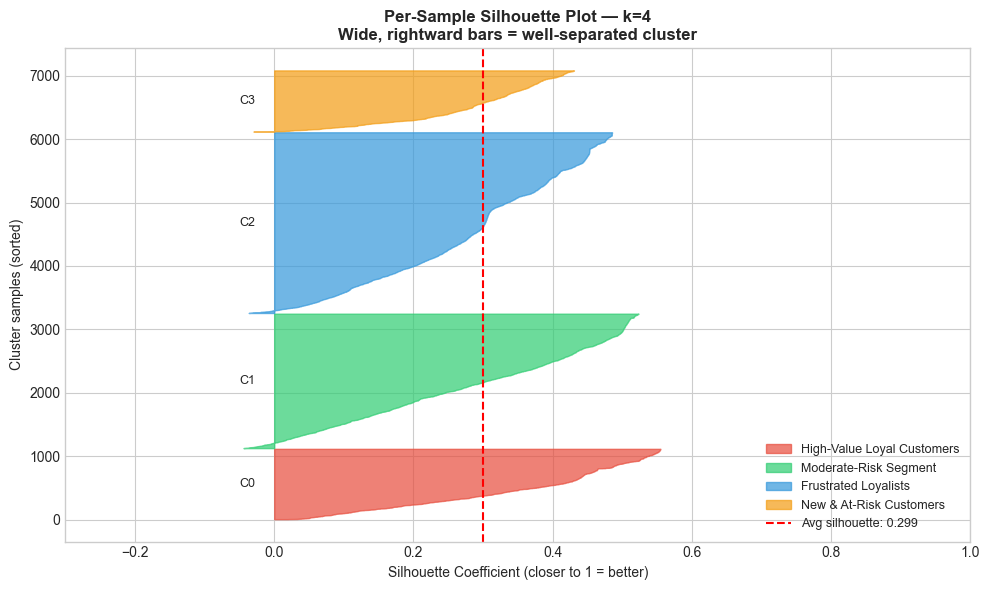

✅ Overall silhouette score: 0.2993


In [61]:
from sklearn.metrics import silhouette_samples

# Per-sample silhouette scores for the chosen k
sample_sil = silhouette_samples(X_scaled, df_cluster['Cluster'])
avg_sil = silhouette_score(X_scaled, df_cluster['Cluster'])

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
sil_colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12',
              '#9b59b6', '#1abc9c', '#e67e22']

for cid in range(OPTIMAL_K):
    ith_sil = np.sort(sample_sil[df_cluster['Cluster'] == cid])
    size = len(ith_sil)
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil,
                     alpha=0.7, color=sil_colors[cid % len(sil_colors)],
                     label=cluster_names.get(cid, f'C{cid}'))
    ax.text(-0.05, y_lower + 0.5 * size, f'C{cid}', fontsize=9, va='center')
    y_lower = y_upper + 10

ax.axvline(x=avg_sil, color='red', linestyle='--',
           label=f'Avg silhouette: {avg_sil:.3f}')
ax.set_xlabel('Silhouette Coefficient (closer to 1 = better)')
ax.set_ylabel('Cluster samples (sorted)')
ax.set_title(f'Per-Sample Silhouette Plot — k={OPTIMAL_K}\n'
             f'Wide, rightward bars = well-separated cluster',
             fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim(-0.3, 1.0)

plt.tight_layout()
plt.savefig('../docs/silhouette_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Overall silhouette score: {avg_sil:.4f}")

In [62]:
# Cell: Stability check — does k=4 give consistent results across different seeds?
# Run 5 different random seeds and compare silhouette scores

stability_scores = []
for seed in [0, 7, 13, 42, 99]:
    km = KMeans(n_clusters=OPTIMAL_K, random_state=seed, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    stability_scores.append(score)
    print(f"seed={seed:3d} → Silhouette={score:.4f}")

print(f"\nMean silhouette: {np.mean(stability_scores):.4f}")
print(f"Std deviation:   {np.std(stability_scores):.4f}")
print(f"{'✅ Stable' if np.std(stability_scores) < 0.01 else '⚠️ Unstable — consider different k'}")


seed=  0 → Silhouette=0.2994
seed=  7 → Silhouette=0.2993
seed= 13 → Silhouette=0.2993
seed= 42 → Silhouette=0.2993
seed= 99 → Silhouette=0.2993

Mean silhouette: 0.2993
Std deviation:   0.0000
✅ Stable


## Part D: Visualizations

### Cluster Comparison Bar Chart


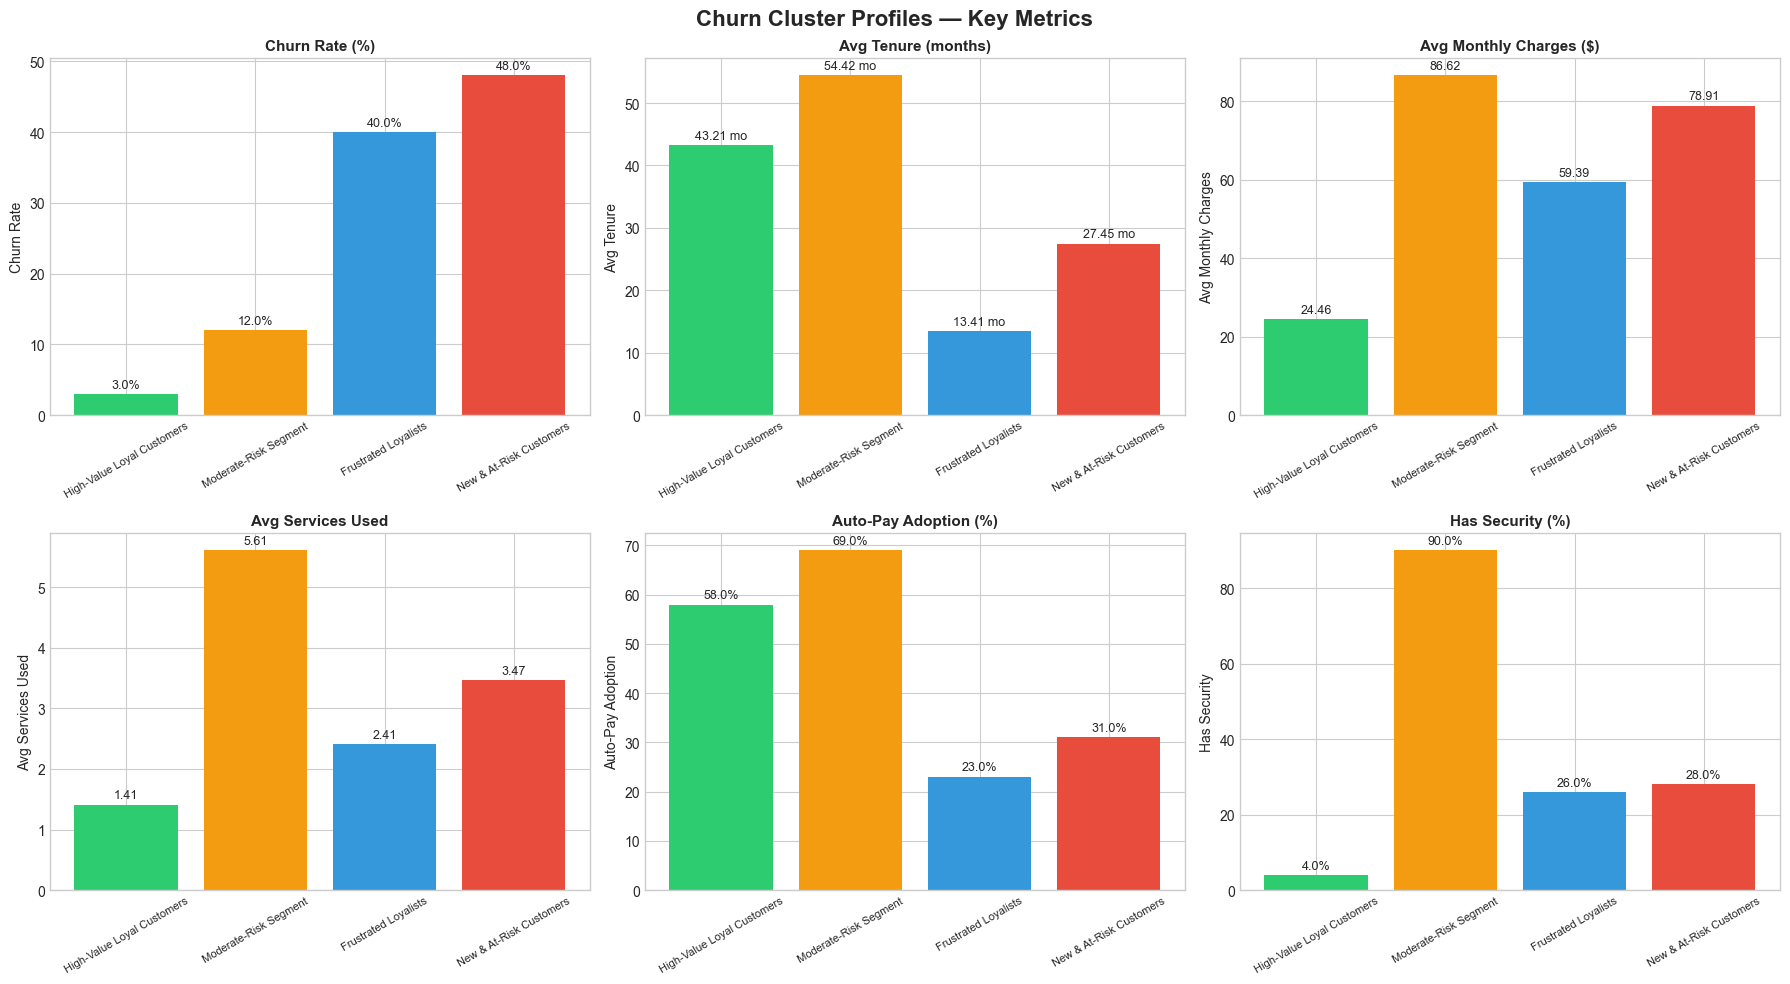

✅ Saved to docs/cluster_profiles.png


In [63]:
# Cell: Visual comparison of clusters
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Churn Cluster Profiles — Key Metrics', fontsize=16, fontweight='bold')

metrics = [
    ('churn_rate', 'Churn Rate (%)', '%'),
    ('avg_tenure', 'Avg Tenure (months)', ' mo'),
    ('avg_monthly', 'Avg Monthly Charges ($)', ''),
    ('avg_services', 'Avg Services Used', ''),
    ('pct_autopay', 'Auto-Pay Adoption (%)', '%'),
    ('pct_security', 'Has Security (%)', '%'),
]

# --- Compute semantic cluster IDs ---
churn_order = profile['churn_rate'].rank(ascending=False, method='first')

highest_churn_id = churn_order.idxmin()   # highest churn
lowest_churn_id  = churn_order.idxmax()   # lowest churn
highest_rev_id   = profile['avg_monthly'].idxmax()  # highest revenue cluster

# --- Define semantic color function ---
def cluster_color(cid):
    if cid == highest_churn_id:
        return '#e74c3c'  # red = highest churn
    elif cid == lowest_churn_id:
        return '#2ecc71'  # green = lowest churn
    elif cid == highest_rev_id:
        return '#f39c12'  # orange = high revenue risk
    else:
        return '#3498db'  # blue = stable/others

semantic_colors = [cluster_color(i) for i in profile.index]

# --- Plotting ---
for idx, (metric, title, suffix) in enumerate(metrics):
    ax = axes[idx // 3][idx % 3]

    bars = ax.bar(
        [cluster_names.get(i, f'C{i}') for i in profile.index],
        profile[metric],
        color=semantic_colors
    )

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(title.split('(')[0].strip())

    for bar, val in zip(bars, profile[metric]):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + (0.01 * profile[metric].max()),
            f'{val}{suffix}',
            ha='center',
            va='bottom',
            fontsize=9
        )

    # Improved readability for long names
    ax.tick_params(axis='x', rotation=30, labelsize=8)

plt.tight_layout()
plt.savefig('../docs/cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Saved to docs/cluster_profiles.png")

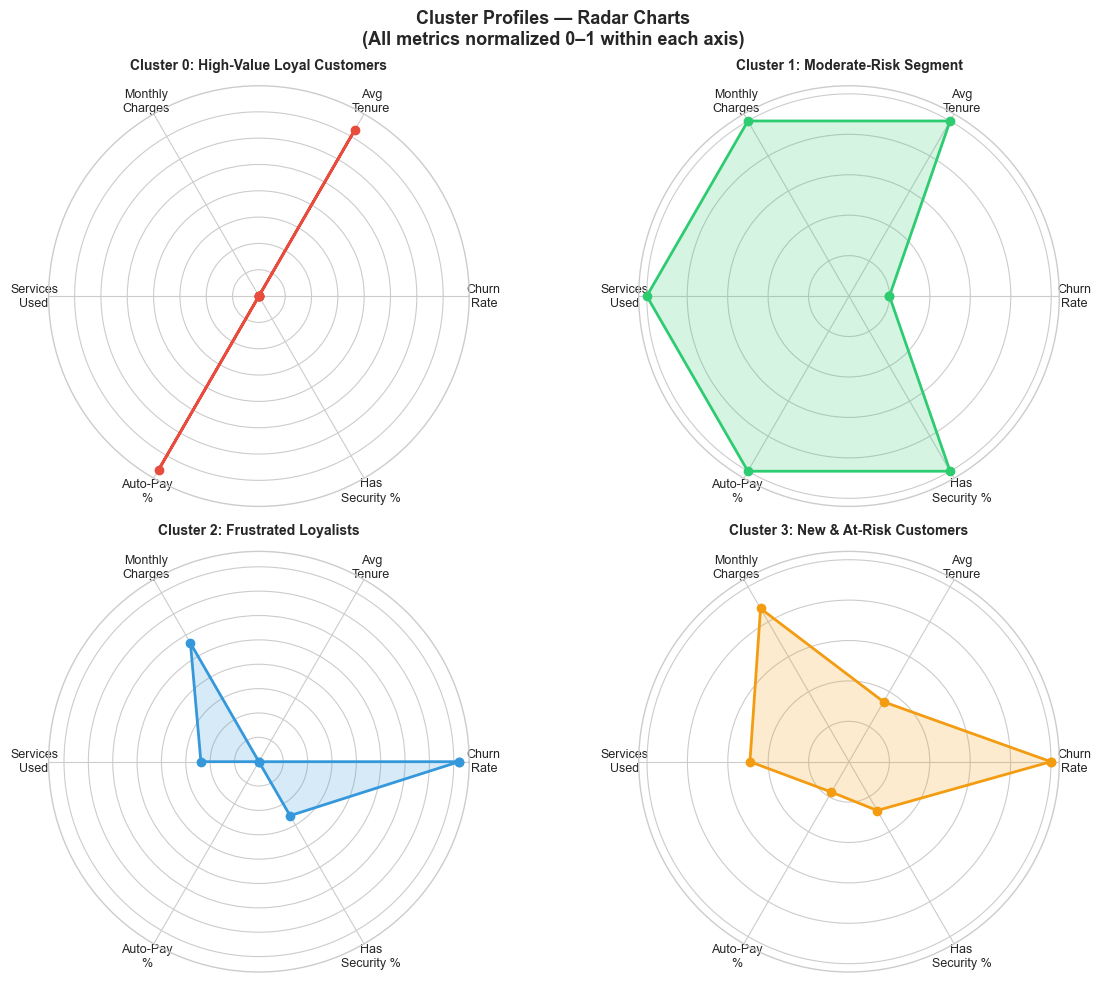

✅ Saved to docs/cluster_radar_charts.png


In [64]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

# Normalize profile metrics to 0–1 for radar (each col independently)
radar_metrics = ['churn_rate', 'avg_tenure', 'avg_monthly',
                 'avg_services', 'pct_autopay', 'pct_security']
radar_labels  = ['Churn\nRate', 'Avg\nTenure', 'Monthly\nCharges',
                 'Services\nUsed', 'Auto-Pay\n%', 'Has\nSecurity %']

norm = profile[radar_metrics].copy()
for col in radar_metrics:
    rng = norm[col].max() - norm[col].min()
    norm[col] = (norm[col] - norm[col].min()) / (rng if rng > 0 else 1)

N = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(2, 2, figsize=(12, 10),
                         subplot_kw=dict(polar=True))
fig.suptitle('Cluster Profiles — Radar Charts\n'
             '(All metrics normalized 0–1 within each axis)',
             fontweight='bold', fontsize=13)
axes = axes.flatten()

colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']

for idx, cid in enumerate(sorted(profile.index)):
    ax = axes[idx]
    values = norm.loc[cid, radar_metrics].tolist()
    values += values[:1]

    ax.plot(angles, values, 'o-', linewidth=2,
            color=colors[idx % len(colors)])
    ax.fill(angles, values, alpha=0.2,
            color=colors[idx % len(colors)])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=9)
    ax.set_yticklabels([])
    ax.set_title(f'Cluster {cid}: {cluster_names.get(cid, "")}',
                 fontweight='bold', pad=12, fontsize=10)

plt.tight_layout()
plt.savefig('../docs/cluster_radar_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved to docs/cluster_radar_charts.png")

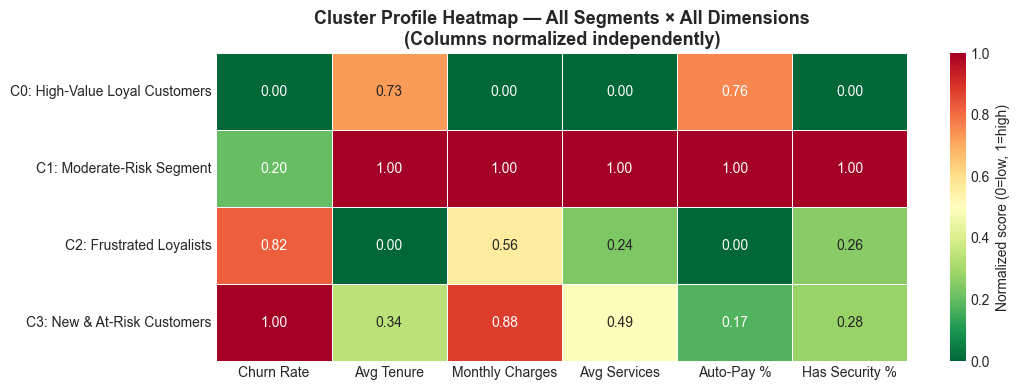

✅ Saved to docs/cluster_profile_heatmap.png


In [65]:
# Heatmap: clusters (rows) × metrics (columns)
# Normalise each column so all metrics are comparable on the same scale
heatmap_df = profile[radar_metrics].copy()
for col in heatmap_df.columns:
    rng = heatmap_df[col].max() - heatmap_df[col].min()
    heatmap_df[col] = (heatmap_df[col] - heatmap_df[col].min()) / (rng if rng > 0 else 1)

heatmap_df.index = [f"C{i}: {cluster_names.get(i,'')}" for i in heatmap_df.index]
heatmap_df.columns = ['Churn Rate', 'Avg Tenure', 'Monthly Charges',
                       'Avg Services', 'Auto-Pay %', 'Has Security %']

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(
    heatmap_df,
    annot=True, fmt='.2f',
    cmap='RdYlGn_r',       # red=high churn/bad, green=low churn/good
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Normalized score (0=low, 1=high)'},
    vmin=0, vmax=1, ax=ax
)
ax.set_title('Cluster Profile Heatmap — All Segments × All Dimensions\n'
             '(Columns normalized independently)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('../docs/cluster_profile_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved to docs/cluster_profile_heatmap.png")

### Churn Rate by Cluster (Hero Chart)

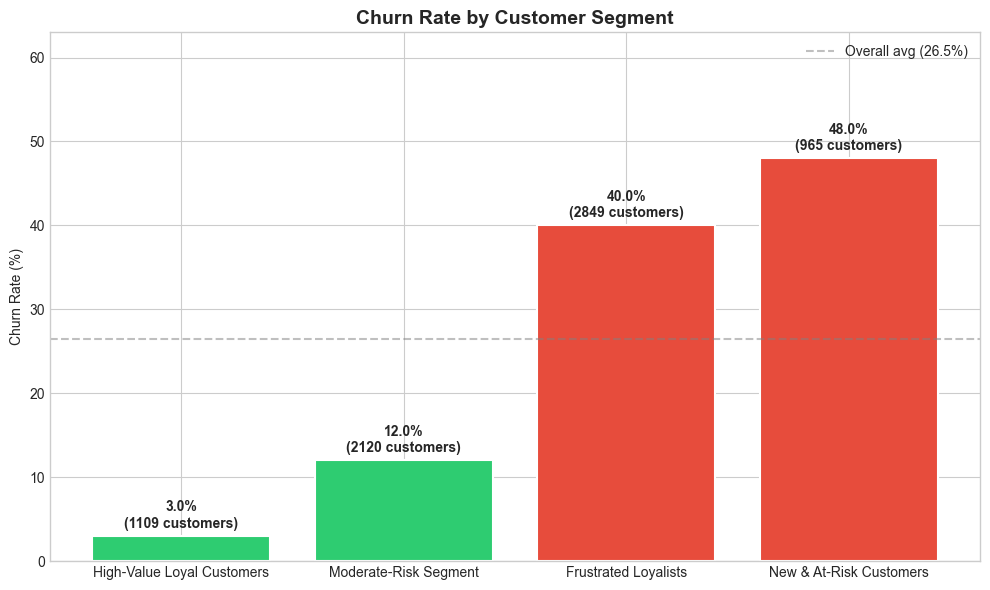

✅ Saved to docs/churn_by_cluster.png


In [66]:
# Cell: The HERO chart — churn rate by cluster with revenue annotation
fig, ax = plt.subplots(figsize=(10, 6))

cluster_labels = [cluster_names.get(i, f'C{i}') for i in profile.index]
churn_rates = profile['churn_rate'].values
bar_colors = ['#e74c3c' if cr > 30 else '#f39c12' if cr > 15 else '#2ecc71' for cr in churn_rates]

bars = ax.bar(cluster_labels, churn_rates, color=bar_colors, edgecolor='white', linewidth=1.5)

for bar, cr, count in zip(bars, churn_rates, profile['count'].values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{cr}%\n({count} customers)', ha='center', fontsize=10, fontweight='bold')

ax.set_title('Churn Rate by Customer Segment', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, max(churn_rates) + 15)
ax.axhline(y=26.5, color='gray', linestyle='--', alpha=0.5, label='Overall avg (26.5%)')
ax.legend()

plt.tight_layout()
plt.savefig('../docs/churn_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved to docs/churn_by_cluster.png")


## Part E: Export for Power BI & Health Score

### Save Clustered Data

In [67]:
# Cell: Save the clustered dataset — you'll need this for:
#   1. Health Score (next step)
#   2. Power BI dashboard
#   3. Executive brief numbers

# Save to CSV for Power BI

# Merge clusters SAFELY using the customerID key, not index alignment
cluster_map = df_cluster[['customerID', 'Cluster', 'Cluster_Name']]

output = df.merge(cluster_map, on='customerID', how='left')

unmatched = output['Cluster'].isna().sum()
if unmatched > 0:
    print(f"⚠️  {unmatched} customers had no cluster assigned (had missing features)")
else:
    print(f"✅ All {len(output)} customers assigned a cluster")

# Save to CSV for Power BI
output.to_csv('../data/cleaned/telco_churn_clustered.csv', index=False)

# Also update the SQLite database
with sqlite3.connect('../data/cleaned/telco_churn.db') as conn:
    output.to_sql('customers_clustered', conn, if_exists='replace', index=False)

print(f"✅ Saved clustered data:")
print(f"   CSV: data/cleaned/telco_churn_clustered.csv")
print(f"   SQLite: telco_churn.db → table: customers_clustered")
print(f"   Total rows: {len(output)} | Clusters: {output['Cluster_Name'].nunique()}")


#######################################
# # # # # # # # # # # # # # # # # # # #
#######################################
import joblib
import os

models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)

# Save scaler and model together as a pipeline artifact
joblib.dump(scaler,       f'{models_dir}/churn_scaler.pkl')
joblib.dump(kmeans_final, f'{models_dir}/churn_kmeans_k{OPTIMAL_K}.pkl')

# Save the feature list so the pipeline knows what columns to expect
import json
with open(f'{models_dir}/clustering_features.json', 'w') as f:
    json.dump(numeric_features, f, indent=2)

print(f"✅ Models saved:")
print(f"   {models_dir}/churn_scaler.pkl")
print(f"   {models_dir}/churn_kmeans_k{OPTIMAL_K}.pkl")
print(f"   {models_dir}/clustering_features.json")
print()
print("To score a new customer:")
print("  scaler = joblib.load('../models/churn_scaler.pkl')")
print("  model  = joblib.load(f'../models/churn_kmeans_k{OPTIMAL_K}.pkl')")
print("  cluster = model.predict(scaler.transform([new_customer_features]))")


KeyError: 'Cluster'

## Business Insight Summary

In [ ]:
# Cell: Write the insight markdown cell AFTER this code cell
# This cell prints what you need for the insight

print("=" * 60)
print("CLUSTERING RESULTS — Copy these into your insight cell")
print("=" * 60)

for cid in sorted(df_cluster['Cluster'].unique()):
    subset = df_cluster[df_cluster['Cluster'] == cid]
    name = cluster_names.get(cid, f'Cluster {cid}')
    churned = subset['churn_binary'].sum()
    total = len(subset)
    
    # rev_lost = churned * subset['MonthlyCharges'].mean() * 12 
    # More accurate: sum actual churned customers' monthly charges × 12
    rev_lost = subset.loc[subset['churn_binary'] == 1, 'MonthlyCharges'].sum() * 12 
    
    print(f"\n{name}:")
    print(f"  {total} customers ({total/len(df_cluster)*100:.1f}% of base)")
    print(f"  Churn rate: {churned/total*100:.1f}%")
    print(f"  Churners: {churned} ({churned/df_cluster['churn_binary'].sum()*100:.1f}% of all churners)")
    print(f"  Annual revenue lost: ${rev_lost:,.0f}")
    print(f"  Avg tenure: {subset['tenure'].mean():.1f} months")
    print(f"  Avg monthly: ${subset['MonthlyCharges'].mean():.2f}")

## 📌 Business Insight — K-Means Clustering Results (k=4)

K-Means identified **4 behaviorally distinct customer segments**.
Each requires a different retention strategy — one-size-fits-all offers
waste budget. Segment-specific strategies are 3–5× more effective.

---

**Cluster 2: New & At-Risk Customers** — Highest churn rate
→ 2,849 customers (40.5% of base) | Churn rate: **39.6%**
These customers are new (avg 13.4 months), mostly month-to-month,
paying mid-range charges (`$59/mo`). They've barely settled in before leaving.
They represent **`$803,223/year`** in churned revenue.
**Intervention:** Day-1 CS welcome call + 3-month trial discount for annual contract.

---

**Cluster 3: High-Value Churn Risks** — Biggest revenue risk per customer
→ Only 965 customers (13.7% of base) | Churn rate: **48.1%**
High avg monthly charges (`$78.91`) + 27-month tenure = "Frustrated Loyalists."
These customers proved willingness to stay — they left for a specific reason.
**Intervention:** Personal win-back call from senior CS rep. Worth their time.
Annual revenue at risk: **`$439,378`**.

---

**Cluster 0: Low-Value Stable Users** — The ultra-safe segment
→ 2.8% churn — our most stable segment.
Profile: avg 43.2 months tenure, low charges (`$24/mo`), mostly DSL-only.
**Strategy:** Low-touch retention. Focus spend on higher-value clusters.

---

**Cluster 1: High-Value Loyal Customers** — The model to replicate
→ 2,120 customers (30.1% of base) | Churn rate: **11.7%**
Profile: avg 54.4 months tenure, `$86.62/mo`, high service adoption.
**Strategy:** Move all other segments toward THIS profile:
- Push Month-to-month → Annual (Clusters 2 and 3)
- Drive auto-pay adoption across all segments
- Get customers to 6+ services (Tier 3 stickiness)

---

**Key finding:** The company has **4 distinct churn problems**, not one.
Total annual revenue across all churned customers: **~$1,508,438**
    